In [1]:
%pip install "numpy<2.0"
%pip install --upgrade gensim
%pip install wordcloud

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
#Confessions on a Dance Floor • 2005 Hung Up
song_nasheed_1 = """
Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
Time goes by so slowly

Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you


Time goes by so slowly for those who wait
No time to hesitate
Those who run seem to have all the fun
I'm caught up, I don't know what to do


Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
I don't know what to do


Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you
Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you
verse

"Ring, ring, ring" goes the telephone
The lights are on, but there's no one home
Tick-tick-tock, it's a quarter to two
And I'm done, I'm hanging up on you
bridge

I can't keep on waiting for you
I know that you're still hesitating
Don't cry for me, 'cause I'll find my way
You'll wake up one day, but it'll be too late
chorus

Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you
Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you
Every little thing, every little thing
I'm hung up, I'm hung up on you
Waiting for your call, waiting for your call
I'm fed up, I'm tired of waiting on you
hook

Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
So slowly, so slowly, so slowly, so slowly
So slowly, so slowly, so slowly, so slowly
So slowly, so slowly, so slowly, so slowly
So slowly, so-, I don't know what to do


Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you
Every little thing that you say or do
I'm hung up, I'm hung up on you
Waiting for your call, baby, night and day
I'm fed up, I'm tired of waiting on you
Every little thing, every little thing
I'm hung up, I'm hung up on you
Waiting for your call, waiting for your call
I'm fed up, I'm tired of waiting on you

"""
#Coyote Stories • 2015 The Moon Will Sing
song_nasheed_2 = """

Tell me once again
I could have been anyone, anyone else
Before you made the choice for me
My feet knew the path
We walked in the dark, in the dark
I never gave a single thought to where it might lead
All those empty rooms
We could have been anywhere, anywhere else
Instead, I made a bed with apathy
My heart knew the weight
Ten years worth of dust and neglect
We made our peace with weariness and let it be


The moon will sing a song for me
I loved you like the sun
Bore the shadows that you made
With no light of my own
I shine only with the light you gave me
I shine only with the light you gave me


Name your courage now
We could have had anything, anything else
Instead, you hoarded all that's left of me
Swallowin' your doubt
Like swords to the pit of my belly
I want to feel the fire that you kept from me


The moon will sing a song for me
I loved you like the sun
Bore the shadows that you made
With no light of my own
I shine only with the light you gave me
I shine only with the light you gave me
I shine only with the light you gave me
(I could have been anyone, anyone)
I shine only with the light you gave me
(I could have been anyone, anyone)

"""
#Animal • 2019 Animal


song_nasheed_3 = """

I tried to love you, but you're not my type
Tried to pretend, but it just don't feel right
To be your number one
Should have known better, I tried to stay cool
You were telling me I'm such a fool to say no
Number one


Make me behave like an animal
Make me behave like an animal
I'm asking nicely, give me what I want
I'll ask politely, give me what I want


I tried to love you, but you're not my type
Tried to pretend, but it just don't feel right
To be your number one


Make me behave like an animal
Make me behave like an animal
I'm asking nicely, give me what I want
I'll ask politely, give me what I want

Make me behave like an animal
Make me behave like an animal
Make me behave like an animal
Make me behave like an animal

"""

songs = [song_nasheed_1, song_nasheed_2, song_nasheed_3]
titles = ["Hung Up", "The Moon Will Sing", "Animal"] # жинка накидала

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    tokens = nltk.word_tokenize(text)
    clean_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            clean_tokens.append(lemma)
    return " ".join(clean_tokens)

processed_songs = [preprocess_text(song) for song in songs]

print("исходник:\n", songs[0][:100].strip(), "...")
print("после обработки:\n", processed_songs[0][:100].strip(), "...")


исходник:
 Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
Time goes by so slowly
Time go ...
после обработки:
 time go slowly time go slowly time go slowly time go slowly time go slowly time go slowly every litt ...


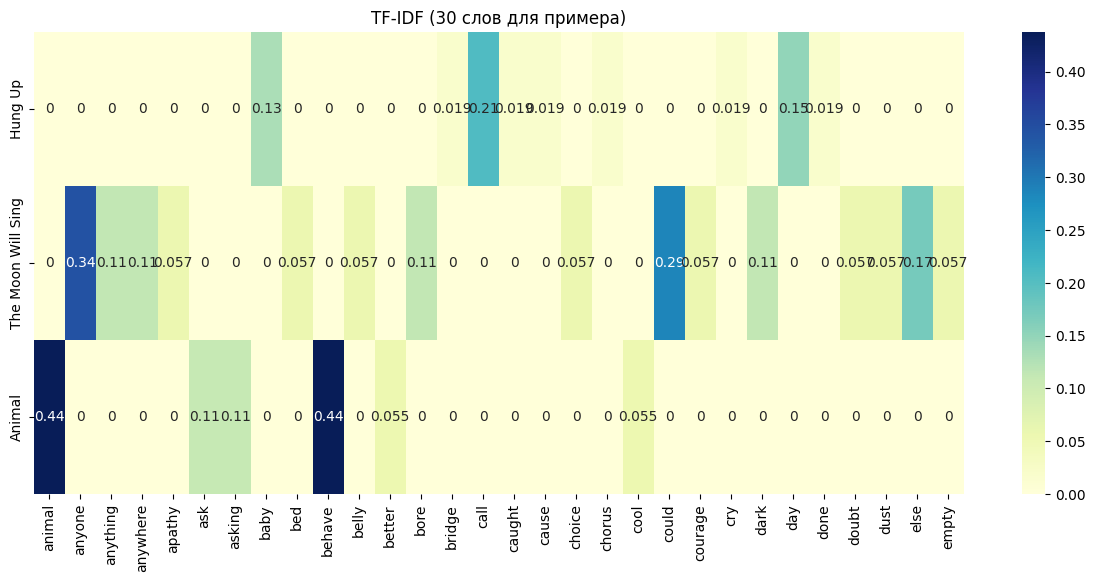

In [5]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_songs)

feature_names = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=titles)

plt.figure(figsize=(15, 6))
sns.heatmap(df_tfidf.iloc[:, :30], annot=True, cmap="YlGnBu", cbar=True)
plt.title("TF-IDF (30 слов для примера)")
plt.show()

Видим, что у слова animal в песне animal наибольший вес, так как логично - это слово повторяется в песне чаще всего. Также неудивительно, что синоним behave встречается.

В The moon will sing could повторяется anyone тип это свзано с депрессией и тд.

In [6]:
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(processed_songs)
df_count = pd.DataFrame(count_matrix.toarray(), columns=count_vectorizer.get_feature_names_out(), index=titles)

print(df_count.iloc[:, :10].head())

tokenized_songs = [song.split() for song in processed_songs]
w2v_model = Word2Vec(sentences=tokenized_songs, vector_size=10, window=5, min_count=1, workers=4)

print("\n\nВектор для слова animal:\n", w2v_model.wv['animal'])

                    animal  anyone  anything  anywhere  apathy  ask  asking  \
Hung Up                  0       0         0         0       0    0       0   
The Moon Will Sing       0       6         2         2       1    0       0   
Animal                   8       0         0         0       0    2       2   

                    baby  bed  behave  
Hung Up                7    0       0  
The Moon Will Sing     0    1       0  
Animal                 0    0       8  


Вектор для слова animal:
 [ 0.10164029 -0.04624364 -0.00113318 -0.05550611  0.03728376  0.02571982
  0.07370965  0.06389021  0.0884546   0.08771431]


Сравнение методов:
1. CountVectorizer - низкая сложность, высокая интепретируемость, не учитывает важность слов
2. TF-IDF - средняя сложность, средняя интерпретируемость, штрафует слова, которые встречаются везде, и выделяет уникальные
3. Word2Vec - высокая сложность, низкая интерпретируемость, учитывает смысл и контекст, синонимы имеют похожие векторы

In [7]:
all_words = " ".join(processed_songs).split()
fdist = nltk.FreqDist(all_words)

print("Топ-10 самых частых слов:")
for word, frequency in fdist.most_common(10):
    print(f"{word}: {frequency}")

print("\n\nТоп-10 самых частых комбинаций слов:")
bigrams = list(nltk.bigrams(all_words))
fdist_bigrams = nltk.FreqDist(bigrams)
for bg, frequency in fdist_bigrams.most_common(10):
    print(f"{bg}: {frequency}")

Топ-10 самых частых слов:
slowly: 27
waiting: 21
hung: 18
time: 15
go: 15
every: 11
little: 11
thing: 11
call: 11
like: 11


Топ-10 самых частых комбинаций слов:
('time', 'go'): 14
('go', 'slowly'): 14
('slowly', 'slowly'): 13
('every', 'little'): 11
('little', 'thing'): 11
('waiting', 'call'): 11
('slowly', 'time'): 10
('hung', 'hung'): 9
('hung', 'waiting'): 9
('fed', 'tired'): 9


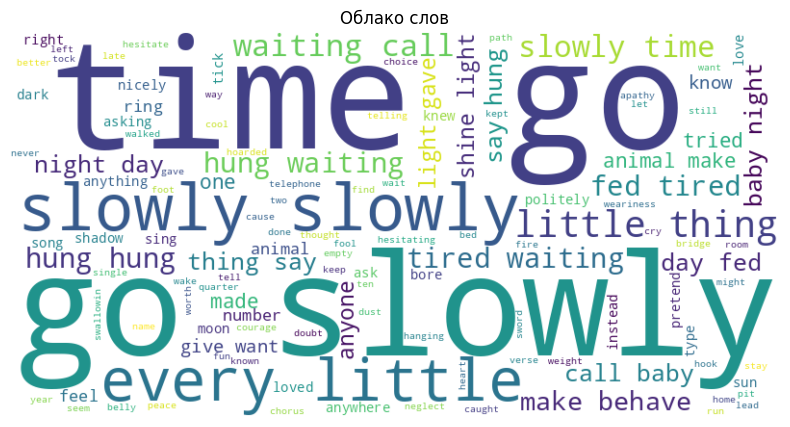

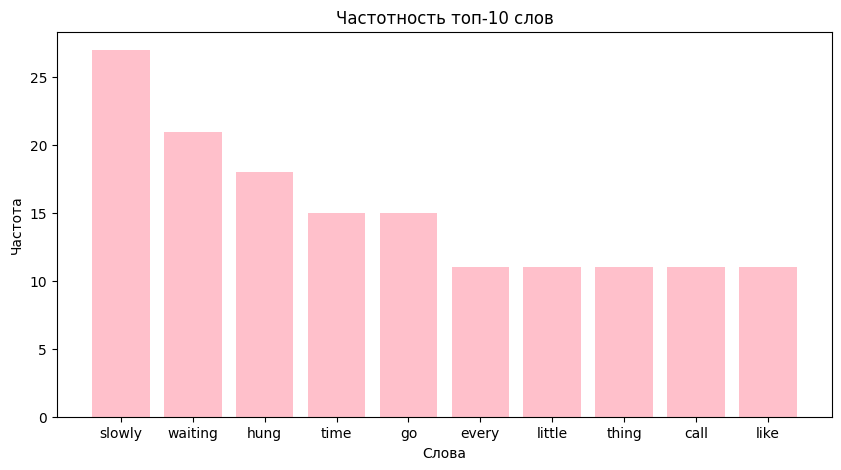

In [9]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(processed_songs))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Облако слов")
plt.show()

top_words = fdist.most_common(10)
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='pink')
plt.title("Частотность топ-10 слов")
plt.xlabel("Слова")
plt.ylabel("Частота")
plt.show()

Главное не спеша все делать)))